In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

RAW_PATH = Path("../data/raw/ecommerce")

In [7]:
events = pd.read_csv(RAW_PATH / "events.csv")
category_tree = pd.read_csv(RAW_PATH / "category_tree.csv")
props1 = pd.read_csv(RAW_PATH / "item_properties_part1.csv")
props2 = pd.read_csv(RAW_PATH / "item_properties_part2.csv")

item_props = pd.concat([props1, props2], ignore_index=True)

print(f"events          : {len(events):>10,} lines | columns: {list(events.columns)}")
print(
    f"item_properties : {len(item_props):>10,} lines | columns: {list(item_props.columns)}"
)
print(
    f"category_tree   : {len(category_tree):>10,} lines | columns: {list(category_tree.columns)}"
)

events          :  2,756,101 lines | columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']
item_properties : 20,275,902 lines | columns: ['timestamp', 'itemid', 'property', 'value']
category_tree   :      1,669 lines | columns: ['categoryid', 'parentid']


### Events Dataset Overview

This section provides an initial overview of the `events.csv` dataset and serves as the starting point of the exploratory data analysis (EDA) process.

Before creating visualizations or performing deeper analysis, it is essential to understand the structure and quality of the raw data. This step focuses on inspecting the dataset's schema and identifying any potential issues that could affect downstream analysis or model training.

Key aspects examined in this cell include:

* Dataset dimensions (number of rows and columns).
* Available features and their meanings.
* Data types for each column.
* Presence of missing or null values.
* General data consistency and quality checks.

Performing this initial inspection helps verify that the data has been loaded correctly and provides a clear understanding of the information available for analysis. It also helps identify potential preprocessing requirements, such as type conversions, missing value handling, or data cleaning steps.

This overview establishes the foundation for all subsequent analyses and ensures that later insights and visualizations are based on a well-understood dataset.


In [8]:
print("=== Overview Of events.csv ===\n")
print(events.dtypes)
print(f"\nNull values:\n{events.isnull().sum()}")
print("\nHEAD:")
events.head()

=== Overview Of events.csv ===

timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Null values:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

HEAD:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


### Timestamp Conversion and Time Range Validation

This step converts the raw timestamp values into a human-readable datetime format, enabling all subsequent time-based analyses.

The `timestamp` field in the dataset is stored as a **Unix timestamp in milliseconds**, which is efficient for storage and processing but not suitable for direct interpretation or temporal analysis. Converting these values to datetime objects is a necessary preprocessing step before exploring trends, seasonality, and user behavior over time.

Key objectives of this transformation include:

* Converting Unix timestamps into readable date and time values.
* Verifying that the timestamp data has been loaded correctly.
* Determining the time period covered by the dataset.
* Preparing the data for temporal visualizations and feature engineering.

This conversion also allows us to identify the dataset's start and end dates, providing a clear understanding of the observation window available for analysis. Knowing the temporal coverage of the data is important for interpreting user behavior, assessing seasonality effects, and designing appropriate train/validation splits for machine learning models.

Since many recommendation system features depend on temporal information, this preprocessing step serves as a critical foundation for all subsequent time-based analyses performed throughout the project.


In [9]:
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")
events["date"] = events["datetime"].dt.date
events["hour"] = events["datetime"].dt.hour
events["dayofweek"] = events["datetime"].dt.day_name()

print("Dataset period: ")
print(f"Start: {events['datetime'].min()}")
print(f"End:   {events['datetime'].max()}")
print(f"Duration: {((events['datetime'].max() - events['datetime'].min()).days)} days")

Dataset period: 
Start: 2015-05-03 03:00:04.384000
End:   2015-09-18 02:59:47.788000
Duration: 137 days


### Event Distribution (Conversion Funnel)

This chart shows the distribution of user events across the e-commerce funnel: **views**, **add-to-cart actions**, and **transactions**.

In a typical online store, these events represent different stages of the **conversion funnel**:

* **Views** represent the top of the funnel, where users browse products.
* **Add-to-cart events** indicate purchase intent and form the middle of the funnel.
* **Transactions** represent completed purchases and therefore the bottom of the funnel.

A significantly lower number of transactions compared to views is expected in most e-commerce platforms, as only a fraction of visitors complete a purchase. This analysis helps quantify the drop-off between each stage and provides a baseline for measuring conversion performance throughout the customer journey.


Conversion funnel:
View:  2,664,312 (100%)
Add to cart:     69,332 (2.60% views)
Transactions:     22,457 (0.84% views)


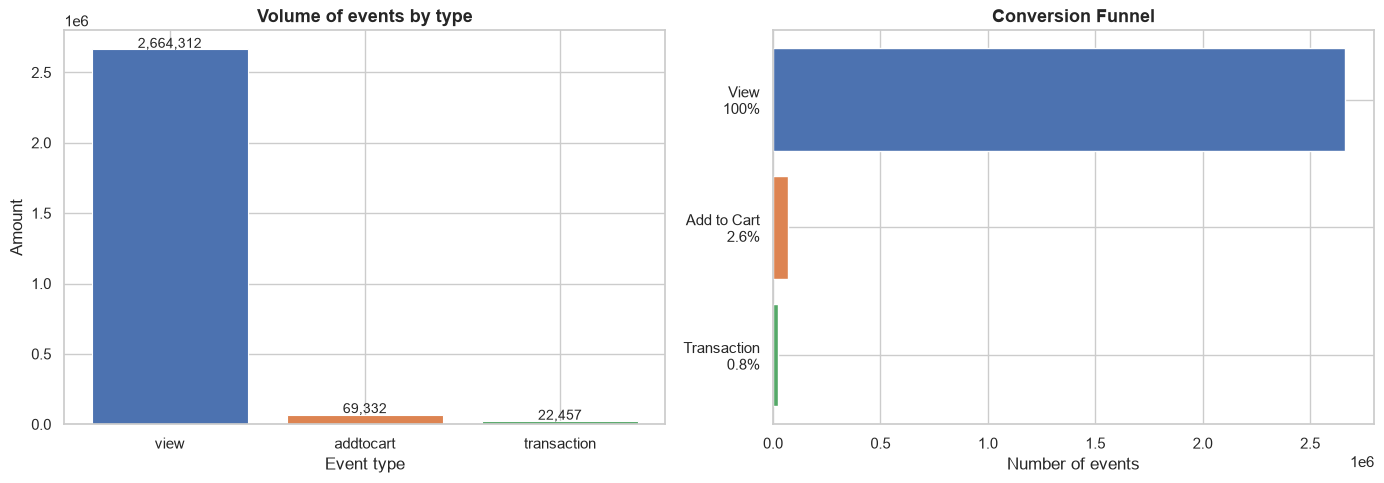

Image saved in notebooks/fig_01_distribution_of_events.png


In [10]:
# Events distribution - Conversion Funnel
event_counts = events["event"].value_counts()
conversion_rate = event_counts["transaction"] / event_counts["view"] * 100
cart_rate = event_counts["addtocart"] / event_counts["view"] * 100

print("Conversion funnel:")
print(f"View: {event_counts['view']:>10,} (100%)")
print(f"Add to cart: {event_counts['addtocart']:>10,} ({cart_rate:.2f}% views)")
print(
    f"Transactions: {event_counts['transaction']:>10,} ({conversion_rate:.2f}% views)"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: contagem absoluta
axes[0].bar(
    event_counts.index,
    event_counts.values,
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="white",
    linewidth=0.8,
)
axes[0].set_title("Volume of events by type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Event type")
axes[0].set_ylabel("Amount")
for i, (val) in enumerate(event_counts.values):
    axes[0].text(i, val + 10000, f"{val:,}", ha="center", fontsize=10)

etapas = [
    "View\n100%",
    f"Add to Cart\n{cart_rate:.1f}%",
    f"Transaction\n{conversion_rate:.1f}%",
]
valores = [event_counts["view"], event_counts["addtocart"], event_counts["transaction"]]
cores = ["#4C72B0", "#DD8452", "#55A868"]
axes[1].barh(etapas, valores, color=cores, edgecolor="white")
axes[1].set_title("Conversion Funnel", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of events")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(
    "../notebooks/fig_01_distribution_of_events.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Image saved in notebooks/fig_01_distribution_of_events.png")

### Temporal Analysis: Daily Event Volume

This chart displays the number of events recorded per day throughout the dataset, providing a time-based view of user activity.

The primary goal of this analysis is to identify **seasonality patterns**, activity trends, and potential anomalies over time. Peaks in event volume may indicate:

* Marketing campaigns or promotional activities.
* Special sales events (e.g., Black Friday, holiday promotions).
* Increased user engagement during specific periods.

Additionally, this visualization helps detect **temporal gaps** in the dataset, such as days with unusually low activity or missing data altogether. Understanding the temporal distribution of events is essential for assessing data quality and ensuring that the dataset accurately reflects real-world user behavior.

This analysis also provides justification for using a **time-based train/validation split**, preventing data leakage and ensuring that model evaluation more closely resembles a real production environment where future events are predicted from historical data.

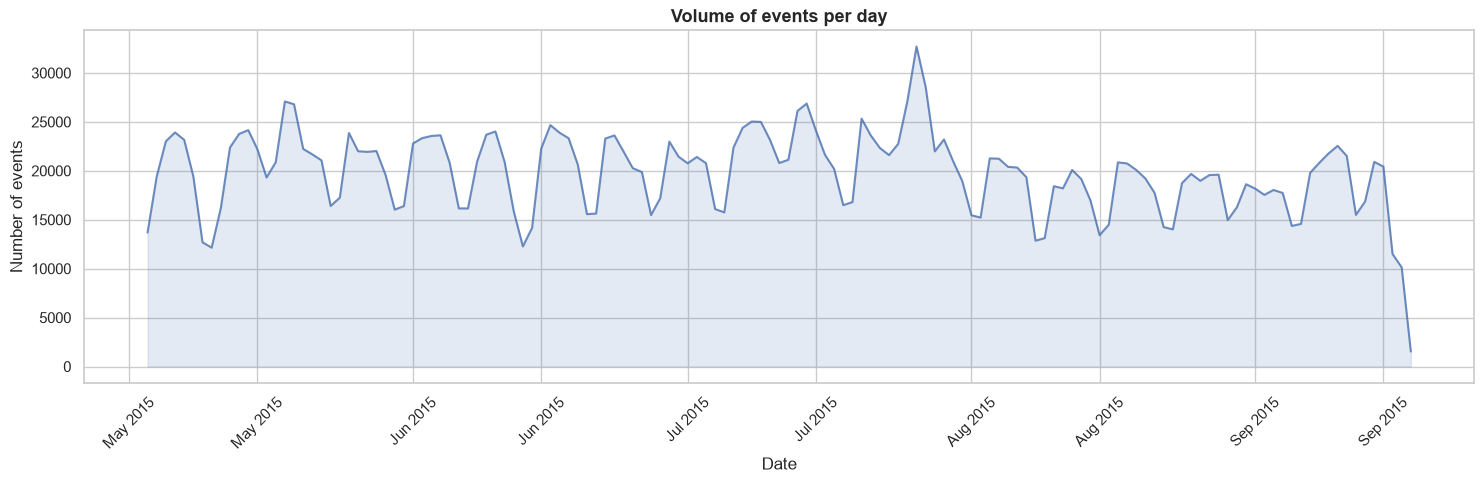

In [11]:
event_per_day = events.groupby("date").size().reset_index(name="count")
event_per_day["date"] = pd.to_datetime(event_per_day["date"])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    event_per_day["date"],
    event_per_day["count"],
    color="#4C72B0",
    linewidth=1.5,
    alpha=0.8,
)
ax.fill_between(
    event_per_day["date"],
    event_per_day["count"],
    alpha=0.15,
    color="#4C72B0",
)

ax.set_title("Volume of events per day", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Number of events")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../notebooks/fig_02_events_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

### User Activity Patterns by Hour of Day and Day of Week

This analysis examines how user activity is distributed across different hours of the day and days of the week, providing insights into temporal engagement patterns.

The objective is to identify **peak activity periods**, understand when users are most active, and uncover behavioral trends that may influence business decisions and system performance. Key insights include:

* **Hourly patterns**, showing when users are most likely to browse, add items to their carts, or complete purchases.
* **Weekly patterns**, highlighting differences in engagement between weekdays and weekends.
* Identification of **peak traffic windows**, which represent periods when the recommendation system has the greatest impact on the user experience.

Understanding these behavioral patterns is valuable from a business perspective, as it helps contextualize user demand, optimize system resources, and prioritize recommendation quality during high-traffic periods. These insights also provide useful business context when presenting the project, particularly in explaining the practical relevance and expected impact of the recommendation system.


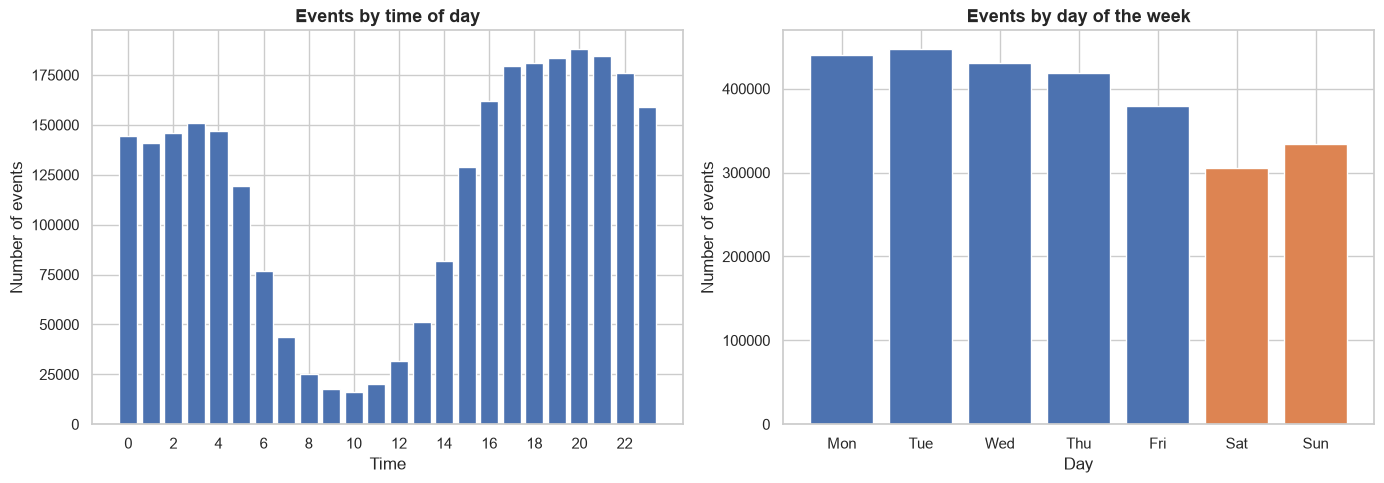

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per hour
events_time = events.groupby("hour").size()
axes[0].bar(
    events_time.index,
    events_time.values,
    color="#4C72B0",
    edgecolor="white",
)
axes[0].set_title("Events by time of day", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Number of events")
axes[0].set_xticks(range(0, 24, 2))

# By day of the week
order_days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
events_week = events.groupby("dayofweek").size().reindex(order_days)
colors_of_week = ["#4C72B0"] * 5 + ["#DD8452"] * 2  # Weekday vs. weekend
axes[1].bar(
    range(len(events_week)),
    events_week.values,
    color=colors_of_week,
    edgecolor="white",
)
axes[1].set_title("Events by day of the week", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of events")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

plt.tight_layout()
plt.savefig("../notebooks/fig_03_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

### User Interaction Distribution Analysis

This analysis explores how user interactions are distributed across the user base, helping to understand engagement levels and data sparsity within the dataset.

In most e-commerce datasets, user activity follows a **power-law distribution**: a small percentage of users generate a large number of interactions, while the majority of users interact only a few times. This behavior is common in recommendation systems and has important implications for model performance.

Key insights from this analysis include:

* Identifying highly active users who contribute a significant portion of the interaction data.
* Measuring the degree of interaction sparsity across the user population.
* Understanding the imbalance between frequent and infrequent users.

This distribution is closely related to the **cold-start problem**, where users with very few interactions provide insufficient information for a recommendation model to learn meaningful preferences. The preprocessing strategy applied in this project addresses this challenge by filtering out users with extremely low activity levels, resulting in a cleaner dataset and more reliable training data for the recommendation system.

By analyzing user interaction patterns before preprocessing, we can better justify the filtering criteria and demonstrate how these decisions improve the quality and robustness of the final model.


User interaction statistics:
  Total unique users: 1,407,580
  Average number of interactions: 2.0
  Median interactions: 1
  Maximum interactions: 7,757
  Users with 1 interaction: 1,001,560 (71.2%)
  Users with >= 5: 81,620 (5.8%)


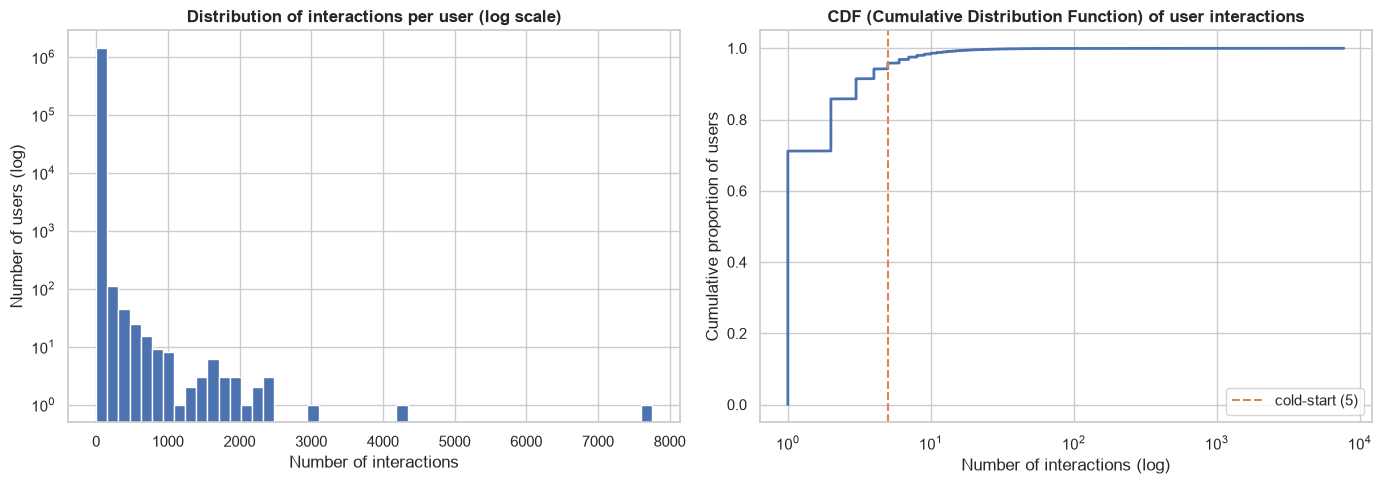

In [13]:
user_interactions = events.groupby("visitorid").size()

print("User interaction statistics:")
print(f"  Total unique users: {len(user_interactions):,}")
print(f"  Average number of interactions: {user_interactions.mean():.1f}")
print(f"  Median interactions: {user_interactions.median():.0f}")
print(f"  Maximum interactions: {user_interactions.max():,}")
print(
    f"  Users with 1 interaction: {(user_interactions == 1).sum():,} "
    f"({(user_interactions == 1).mean():.1%})"
)
print(
    f"  Users with >= 5: {(user_interactions >= 5).sum():,} "
    f"({(user_interactions >= 5).mean():.1%})"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (escala log)
axes[0].hist(
    user_interactions.values,
    bins=50,
    color="#4C72B0",
    edgecolor="white",
    log=True,
)
axes[0].set_title(
    "Distribution of interactions per user (log scale)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Number of interactions")
axes[0].set_ylabel("Number of users (log)")

# Cumulative Distribution Function
sorted_counts = np.sort(user_interactions.values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, color="#4C72B0", linewidth=2)
axes[1].axvline(x=5, color="#DD8452", linestyle="--", label="cold-start (5)")
axes[1].set_xscale("log")
axes[1].set_title(
    "CDF (Cumulative Distribution Function) of user interactions",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Number of interactions (log)")
axes[1].set_ylabel("Cumulative proportion of users")
axes[1].legend()

plt.tight_layout()
plt.savefig("../notebooks/fig_04_distribution_users.png", dpi=150, bbox_inches="tight")
plt.show()

### Item Interaction Distribution Analysis

This analysis examines how interactions are distributed across items in the catalog, helping to identify popularity patterns and understand the structure of user engagement within the dataset.

Similar to user activity, item interactions in e-commerce datasets typically follow a **power-law distribution**. A relatively small number of highly popular items accumulate a large share of all interactions, while the majority of items receive only limited attention.

Key insights from this analysis include:

* Identifying the most popular items that dominate user engagement.
* Measuring the level of popularity concentration across the catalog.
* Understanding the imbalance between frequently interacted and rarely interacted items.

This behavior has important implications for recommendation systems. Because a small set of popular items naturally attracts a large portion of interactions, a simple **popularity-based recommender** often performs surprisingly well and can serve as a strong baseline. As a result, more advanced recommendation models must demonstrate that they provide value beyond merely recommending the most popular products.

Analyzing the item interaction distribution helps explain why popularity-based methods are difficult to outperform and provides valuable context when evaluating the effectiveness of more sophisticated recommendation approaches developed throughout this project.


Item interaction statistics:
  Total unique items      : 235,061
  Average interactions    : 11.7
  Median interactions     : 3
  Maximum interactions    : 3,412
  Items with 1 interaction: 73,609 (31.3%)


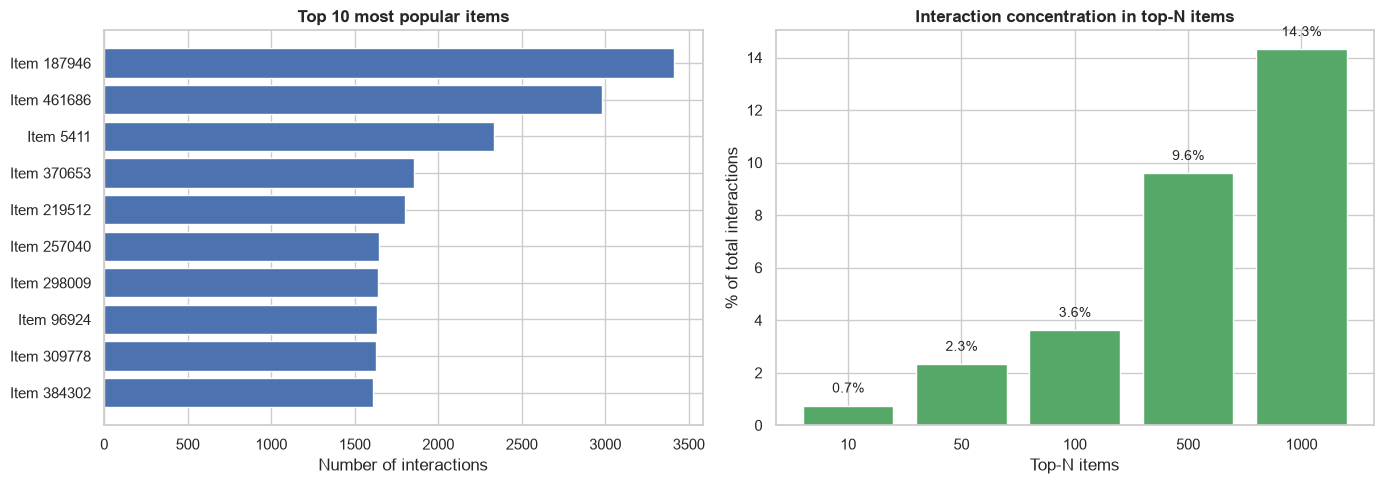

In [14]:
interactions_per_item = events.groupby("itemid").size()

print("Item interaction statistics:")
print(f"  Total unique items      : {len(interactions_per_item):,}")
print(f"  Average interactions    : {interactions_per_item.mean():.1f}")
print(f"  Median interactions     : {interactions_per_item.median():.0f}")
print(f"  Maximum interactions    : {interactions_per_item.max():,}")
print(
    f"  Items with 1 interaction: {(interactions_per_item == 1).sum():,} "
    f"({(interactions_per_item == 1).mean():.1%})"
)

# Top 10 most popular items
top_items = interactions_per_item.nlargest(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    [f"Item {i}" for i in top_items.index],
    top_items.values,
    color="#4C72B0",
    edgecolor="white",
)
axes[0].set_title("Top 10 most popular items", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of interactions")
axes[0].invert_yaxis()

# Concentration: % of interactions in the top-N items
total_interactions = len(events)
top_ns = [10, 50, 100, 500, 1000]
concentration = [
    interactions_per_item.nlargest(n).sum() / total_interactions * 100 for n in top_ns
]

axes[1].bar(
    [str(n) for n in top_ns],
    concentration,
    color="#55A868",
    edgecolor="white",
)
axes[1].set_title(
    "Interaction concentration in top-N items", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Top-N items")
axes[1].set_ylabel("% of total interactions")

for i, v in enumerate(concentration):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../notebooks/fig_05_item_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### User–Item Matrix Sparsity Analysis

This analysis measures the **sparsity** of the user–item interaction matrix, one of the most important metrics in recommendation system development.

The user–item matrix represents all possible interactions between users and items in the catalog. Sparsity quantifies the percentage of matrix entries that contain no interaction. In other words, it measures how much of the potential user–item space remains empty.

Key insights from this analysis include:

* Understanding the density of available interaction data.
* Quantifying how much information is available for learning user preferences.
* Evaluating the complexity of the recommendation problem.

In e-commerce environments, extremely high sparsity levels are expected and are typically considered normal. Most users interact with only a tiny fraction of the available catalog, meaning that the vast majority of user–item combinations never occur. It is common to observe sparsity values above 99%, where a typical user may interact with less than 0.1% of all available products.

This characteristic presents a significant challenge for recommendation systems because the raw user–item matrix contains very little information relative to its size. As a result, directly modeling the matrix is often inefficient and ineffective.

The high sparsity observed in this dataset provides strong justification for using **embedding-based approaches**, which learn compact latent representations of users and items. Embeddings allow the model to capture hidden relationships and similarities despite the limited number of observed interactions, making them particularly well-suited for large-scale recommendation problems with sparse data.


In [15]:
n_users = events["visitorid"].nunique()
n_items = events["itemid"].nunique()
n_interactions = len(events.drop_duplicates(["visitorid", "itemid"]))
total_possible = n_users * n_items
sparsity = (1 - n_interactions / total_possible) * 100

print("=" * 50)
print("USER-ITEM MATRIX SPARSITY")
print("=" * 50)
print(f"  Unique users             : {n_users:>12,}")
print(f"  Unique items             : {n_items:>12,}")
print(f"  Matrix size              : {total_possible:>12,}")
print(f"  Unique interactions      : {n_interactions:>12,}")
print(f"  Sparsity                 : {sparsity:>11.4f}%")
print(f"  Density                  : {100 - sparsity:>11.6f}%")
print("=" * 50)
print(f"\nInterpretation: only {100 - sparsity:.4f}% of the matrix is filled.")

USER-ITEM MATRIX SPARSITY
  Unique users             :    1,407,580
  Unique items             :      235,061
  Matrix size              : 330,867,162,380
  Unique interactions      :    2,145,179
  Sparsity                 :     99.9994%
  Density                  :    0.000648%

Interpretation: only 0.0006% of the matrix is filled.


### Category Tree Hierarchy Analysis

This analysis explores the structure of the product category hierarchy defined in the `category_tree` dataset. Understanding this hierarchy provides valuable business context and helps explain how products are organized within the catalog.

The category tree represents a parent–child relationship between categories, forming a hierarchical taxonomy that ranges from broad product groups to highly specific product classifications.

Key insights from this analysis include:

* Identifying **top-level categories** that serve as broad organizational groups for the catalog.
* Detecting **high-degree parent categories** (often referred to as "umbrella categories") that contain many subcategories. Examples in a typical e-commerce platform might include categories such as Electronics, Home & Garden, or Fashion.
* Identifying **leaf categories**, which have no children and represent the most granular level of product classification.
* Understanding the overall complexity and depth of the category structure.

Analyzing the category hierarchy helps provide important business context by revealing how products are grouped and navigated within the platform. This information can be valuable when interpreting user behavior, understanding item relationships, and explaining the business domain to stakeholders.

Additionally, the category tree serves as contextual information for the recommendation system, as category relationships can later be leveraged for feature engineering, content-based recommendations, and improved product discovery strategies.


Category tree structure:
  Total categories     : 1,669
  Root categories      : 25 (without parentid)
  Child categories     : 1644
  Average children     : 4.5
  Maximum children     : 31


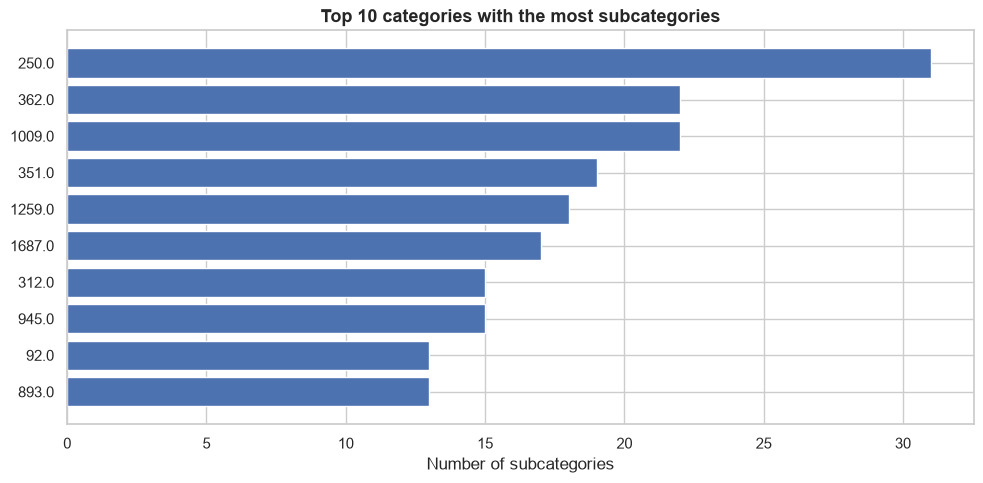

In [16]:
# Identify root categories (without parent)
root_categories = category_tree[category_tree["parentid"].isna()]
child_categories = category_tree[category_tree["parentid"].notna()]

# Count how many children each category has
children_per_category = (
    category_tree.groupby("parentid").size().reset_index(name="n_children")
)
top_parents = children_per_category.nlargest(10, "n_children")

print("Category tree structure:")
print(f"  Total categories     : {len(category_tree):,}")
print(f"  Root categories      : {len(root_categories)} (without parentid)")
print(f"  Child categories     : {len(child_categories)}")
print(f"  Average children     : {children_per_category['n_children'].mean():.1f}")
print(f"  Maximum children     : {children_per_category['n_children'].max()}")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    top_parents["parentid"].astype(str),
    top_parents["n_children"],
    color="#4C72B0",
    edgecolor="white",
)

ax.set_title(
    "Top 10 categories with the most subcategories", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Number of subcategories")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../notebooks/fig_06_categories.png", dpi=150, bbox_inches="tight")
plt.show()

### Executive Summary for STAR Presentation

This cell generates a consolidated summary of the key findings from the exploratory data analysis (EDA). The purpose of this summary is to provide a concise, business-oriented overview of the dataset and the challenges that will be addressed throughout the project.

The metrics and insights presented here serve as the foundation for communicating the project's context to stakeholders and are particularly useful when structuring the **Situation** section of the STAR (Situation, Task, Action, Result) framework.

Key information typically included in this summary may consist of:

* Dataset size and overall interaction volume.
* Number of users and items.
* Event distribution across views, add-to-cart actions, and transactions.
* User and item interaction patterns.
* User–item matrix sparsity.
* Temporal activity trends and seasonality.
* Category hierarchy characteristics.
* Other relevant business and technical insights discovered during the EDA process.

By consolidating the most important findings into a single view, this section provides a clear narrative of the business problem, the characteristics of the data, and the challenges involved in building an effective recommendation system. These insights help establish the context for the subsequent modeling decisions and serve as a reference point when presenting the project's objectives, methodology, and outcomes.


In [17]:
print("=" * 60)
print("DATASET SUMMARY - RETAILROCKET ECOMMERCE")
print("=" * 60)

interactions_per_user = events.groupby("visitorid").size()
interactions_per_item = events.groupby("itemid").size()
event_counts = events["event"].value_counts()

print(f"""
DATASET:
  Covered period     : {events["datetime"].min().date()} to {events["datetime"].max().date()}
  Total events       : {len(events):,}

USERS:
  Unique users       : {events["visitorid"].nunique():,}
  Avg. interactions  : {interactions_per_user.mean():.1f} per user
  Users >= 5 int.    : {(interactions_per_user >= 5).sum():,} ({(interactions_per_user >= 5).mean():.1%})

ITEMS:
  Unique items       : {events["itemid"].nunique():,}
  Avg. interactions  : {interactions_per_item.mean():.1f} per item
  Categories         : {len(category_tree):,}

CONVERSION FUNNEL:
  Views              : {event_counts["view"]:,} (100%)
  Add to Cart        : {event_counts["addtocart"]:,} ({event_counts["addtocart"] / event_counts["view"] * 100:.2f}%)
  Transactions       : {event_counts["transaction"]:,} ({event_counts["transaction"] / event_counts["view"] * 100:.2f}%)

DATA QUALITY:
  Sparsity           : {sparsity:>11.4f}%
  Feedback type      : Implicit (behavioral events)
  Assigned scores    : view=1.0, addtocart=2.0, transaction=3.0
""")

print("=" * 60)

DATASET SUMMARY - RETAILROCKET ECOMMERCE

DATASET:
  Covered period     : 2015-05-03 to 2015-09-18
  Total events       : 2,756,101

USERS:
  Unique users       : 1,407,580
  Avg. interactions  : 2.0 per user
  Users >= 5 int.    : 81,620 (5.8%)

ITEMS:
  Unique items       : 235,061
  Avg. interactions  : 11.7 per item
  Categories         : 1,669

CONVERSION FUNNEL:
  Views              : 2,664,312 (100%)
  Add to Cart        : 69,332 (2.60%)
  Transactions       : 22,457 (0.84%)

DATA QUALITY:
  Sparsity           :     99.9994%
  Feedback type      : Implicit (behavioral events)
  Assigned scores    : view=1.0, addtocart=2.0, transaction=3.0



### Preprocessing Filter Simulation and Data Retention Analysis

This analysis simulates the filtering logic that will later be applied during the preprocessing stage, allowing us to evaluate its impact on the dataset before executing the full pipeline.

Rather than applying the preprocessing steps as a black box, this cell provides visibility into how each filtering criterion affects the data. By measuring the number of records, users, and items retained after each stage, we can validate whether the chosen thresholds are reasonable and aligned with the project's objectives.

Key objectives of this analysis include:

* Reproducing the exact filtering strategy used by the preprocessing pipeline.
* Measuring how much data is removed at each filtering step.
* Evaluating the impact of user and item activity thresholds.
* Identifying potential over-filtering or excessive data loss.
* Verifying that sufficient data remains for model training and evaluation.

This simulation serves as a validation step before running the complete preprocessing workflow. By understanding the effect of each filter in advance, we can make informed decisions about data quality trade-offs and ensure that the final dataset maintains a balance between reducing noise and preserving meaningful interactions.

The results of this analysis provide transparency into the preprocessing process and help justify the filtering decisions that will ultimately shape the training data used by the recommendation system.


In [18]:
print("=== COLD-START FILTER SIMULATION ===\n")

# Aggregate events by user-item pair (same as the preprocessor)
df_agg = events.groupby(["visitorid", "itemid"], as_index=False).agg(
    rating=(
        "event",
        lambda x: x.map({"view": 1.0, "addtocart": 2.0, "transaction": 3.0}).max(),
    ),
    timestamp=("timestamp", "max"),
)

print("After aggregation (1 row per user-item pair):")
print(f"  Unique pairs: {len(df_agg):,}")

# Simulate iterative filters
for min_interactions in [5, 10, 15, 20]:
    df_temp = df_agg.copy()

    for _ in range(5):
        user_counts = df_temp["visitorid"].value_counts()
        item_counts = df_temp["itemid"].value_counts()

        valid_users = user_counts[user_counts >= min_interactions].index
        valid_items = item_counts[item_counts >= min_interactions].index

        df_temp = df_temp[
            df_temp["visitorid"].isin(valid_users) & df_temp["itemid"].isin(valid_items)
        ]

    n_users = df_temp["visitorid"].nunique()
    n_items = df_temp["itemid"].nunique()
    n_interactions = len(df_temp)
    sparsity = (1 - n_interactions / (n_users * n_items)) * 100

    print(f"\n  Filter >= {min_interactions} interactions:")
    print(f"    Users       : {n_users:>8,}")
    print(f"    Items       : {n_items:>8,}")
    print(f"    Interactions: {n_interactions:>8,}")
    print(f"    Sparsity    : {sparsity:.4f}%")

=== COLD-START FILTER SIMULATION ===

After aggregation (1 row per user-item pair):
  Unique pairs: 2,145,179

  Filter >= 5 interactions:
    Users       :   23,620
    Items       :   19,230
    Interactions:  255,398
    Sparsity    : 99.9438%

  Filter >= 10 interactions:
    Users       :    1,502
    Items       :    2,598
    Interactions:   40,574
    Sparsity    : 98.9602%

  Filter >= 15 interactions:
    Users       :      160
    Items       :      384
    Interactions:    7,299
    Sparsity    : 88.1201%

  Filter >= 20 interactions:
    Users       :       53
    Items       :       90
    Interactions:    1,875
    Sparsity    : 60.6918%


### Final Configuration Validation and Metadata Export

This step validates the final dataset configuration after preprocessing and exports key metadata required by downstream components of the machine learning pipeline.

The primary objective is to capture essential dataset statistics that will be needed during model training and deployment. Rather than hardcoding these values, they are automatically generated and stored as metadata, ensuring consistency across all stages of the project.

Key tasks performed in this cell include:

* Confirming the final number of users retained after preprocessing.
* Confirming the final number of items retained after preprocessing.
* Validating that the filtered dataset matches the expected configuration.
* Exporting metadata for use in downstream pipeline stages.

Saving this metadata is particularly important for recommendation models that rely on **embedding layers**. The size of user and item embedding tables depends directly on the total number of unique users and items present in the processed dataset. By storing these values as metadata, the training pipeline can automatically configure model dimensions without requiring manual updates whenever the dataset changes.

The metadata is exported in **JSON format**, making it lightweight, human-readable, and easy for other pipeline components to consume programmatically. This approach improves reproducibility, reduces configuration errors, and enables seamless integration with automated workflows such as DVC pipelines and model training stages.

By externalizing these dataset characteristics into a dedicated metadata file, the project maintains a clear separation between data processing, configuration, and model training, resulting in a more scalable and maintainable machine learning workflow.

In [19]:
import json

# Selected configuration
MIN_INTERACTIONS = 10

# Apply final filter
df_final = df_agg.copy()

for _ in range(5):
    user_counts = df_final["visitorid"].value_counts()
    item_counts = df_final["itemid"].value_counts()

    valid_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    valid_items = item_counts[item_counts >= MIN_INTERACTIONS].index

    df_final = df_final[
        df_final["visitorid"].isin(valid_users) & df_final["itemid"].isin(valid_items)
    ]

n_users_final = df_final["visitorid"].nunique()
n_items_final = df_final["itemid"].nunique()
n_interactions_final = len(df_final)
final_sparsity = (1 - n_interactions_final / (n_users_final * n_items_final)) * 100

print("=" * 55)
print("FINAL DATASET CONFIGURATION")
print("=" * 55)
print(f"  Cold-start filter       : >= {MIN_INTERACTIONS} interactions")
print(f"  Users                   : {n_users_final:,}")
print(f"  Items                   : {n_items_final:,}")
print(f"  Interactions            : {n_interactions_final:,}")
print(f"  Sparsity                : {final_sparsity:.4f}%")
print(f"  Average per user        : {n_interactions_final / n_users_final:.1f}")
print(f"  Average per item        : {n_interactions_final / n_items_final:.1f}")
print("=" * 55)

# Save metadata for the pipeline to use
metadata = {
    "dataset": "retailrocket",
    "min_interactions": MIN_INTERACTIONS,
    "num_users": n_users_final,
    "num_items": n_items_final,
    "num_interactions": n_interactions_final,
    "sparsity": round(final_sparsity, 6),
}

Path("../data/processed").mkdir(parents=True, exist_ok=True)

with open("../data/processed/dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\nMetadata saved to data/processed/dataset_metadata.json")
print("\nThese numbers go into the STAR video - Situation section:")
print(f'  "The RetailRocket dataset contains {n_interactions_final:,} interactions')
print(f"   from {n_users_final:,} users with {n_items_final:,} products,")
print(f'   with {final_sparsity:.2f}% sparsity - typical of real e-commerce."')

FINAL DATASET CONFIGURATION
  Cold-start filter       : >= 10 interactions
  Users                   : 1,502
  Items                   : 2,598
  Interactions            : 40,574
  Sparsity                : 98.9602%
  Average per user        : 27.0
  Average per item        : 15.6

Metadata saved to data/processed/dataset_metadata.json

These numbers go into the STAR video - Situation section:
  "The RetailRocket dataset contains 40,574 interactions
   from 1,502 users with 2,598 products,
   with 98.96% sparsity - typical of real e-commerce."


### Final EDA Summary — Key Decisions and Rationale

This section concludes the exploratory data analysis (EDA) by summarizing the most important findings, the decisions made throughout the analysis, and the reasoning behind those decisions.

The purpose of this summary is to connect the insights discovered during the EDA phase with the subsequent preprocessing, feature engineering, and modeling steps. Rather than simply presenting descriptive statistics, this section explains how the observed characteristics of the dataset influenced the overall project strategy.

Key topics typically covered include:

* Major findings about user behavior and item popularity.
* Dataset quality observations and preprocessing requirements.
* User and item filtering decisions.
* Sparsity considerations and their impact on model selection.
* Temporal characteristics of the data and validation strategy.
* Business insights derived from event and category analysis.
* Justification for the chosen recommendation approach.

This summary serves as a bridge between data exploration and model development, providing a clear narrative of how the project evolved from understanding the data to designing a recommendation solution.

Additionally, this section is intended to support project communication and stakeholder presentations. It consolidates the most relevant insights and decisions into a concise format that can be referenced when explaining the project's context, challenges, and technical choices—making it particularly useful for the **Situation** portion of a STAR (Situation, Task, Action, Result) presentation.


In [20]:
print("""
╔══════════════════════════════════════════════════════════╗
║           CONCLUSÕES DA EDA — DECISÕES TOMADAS           ║
╚══════════════════════════════════════════════════════════╝

1. DATASET ESCOLHIDO: RetailRocket Ecommerce Dataset
   • Feedback implícito real de e-commerce (não sintético)
   • 3 tipos de evento com intensidade crescente de intenção
   • Período de 4.5 meses (mai-set 2015)

2. CONVERSÃO DE EVENTOS PARA SCORES:
   • view        → 1.0  (interesse básico)
   • addtocart   → 2.0  (intenção de compra)
   • transaction → 3.0  (conversão real)
   Justificativa: captura a intensidade de intenção do usuário.
   Uma compra vale mais que um clique acidental.

3. FILTRO DE COLD-START: >= 10 interações
   • Usuários com poucas interações não geram embeddings confiáveis
   • Com >= 10: 1.502 usuários · 2.598 itens · 40.574 interações
   • Média de 27 interações/usuário — suficiente para o modelo aprender
   • Esparsidade: 98.96% — ainda desafiador, mas tratável

4. SPLIT TEMPORAL (não aleatório):
   • Treino  : 80% mais antigos (eventos até ago/2015)
   • Val     : 10% seguintes
   • Teste   : 10% mais recentes (eventos set/2015)
   Justificativa: evita vazamento de dados futuros no treino.
   Simula o cenário real de produção.

5. NORMALIZAÇÃO DE RATINGS:
   • Min-max para [0, 1] — compatível com Sigmoid do MLP

6. AGGREGAÇÃO DE EVENTOS:
   • Múltiplos eventos do mesmo par usuário-item → score máximo
   • Preserva o timestamp mais recente para o split temporal

7. CATEGORY_TREE:
   • 1.669 categorias em hierarquia de múltiplos níveis
   • Usada para análise e contexto de negócio
   • Feature engineering opcional em versões futuras do modelo
""")


╔══════════════════════════════════════════════════════════╗
║           CONCLUSÕES DA EDA — DECISÕES TOMADAS           ║
╚══════════════════════════════════════════════════════════╝

1. DATASET ESCOLHIDO: RetailRocket Ecommerce Dataset
   • Feedback implícito real de e-commerce (não sintético)
   • 3 tipos de evento com intensidade crescente de intenção
   • Período de 4.5 meses (mai-set 2015)

2. CONVERSÃO DE EVENTOS PARA SCORES:
   • view        → 1.0  (interesse básico)
   • addtocart   → 2.0  (intenção de compra)
   • transaction → 3.0  (conversão real)
   Justificativa: captura a intensidade de intenção do usuário.
   Uma compra vale mais que um clique acidental.

3. FILTRO DE COLD-START: >= 10 interações
   • Usuários com poucas interações não geram embeddings confiáveis
   • Com >= 10: 1.502 usuários · 2.598 itens · 40.574 interações
   • Média de 27 interações/usuário — suficiente para o modelo aprender
   • Esparsidade: 98.96% — ainda desafiador, mas tratável

4. SPLIT TEMPO